# Notebook 2 — Charisma: Final Strategy (analyst revisions vs. industry momentum)

**MFE 230GA Active Asset Management — Final Project, Group 4**
Hashim Almodamagha, Aditya Aryan, Jack Duncan, Charishma Takkallapalli, Cristhian Ruiz Cardozo

This is the **main empirical analysis** of the final project, discussed in `MFE230GA_Final_Project.pdf` (Section 4).
It builds every table and figure of that section from the validated results. The outputs shown are from the executed run.
No WRDS access is needed to read or rerun it: the industry-level signal panels are in `data/charisma/processed/`.

## 1. Research question and falsification criterion

**Question.** Do industry-level analyst EPS revisions contain information about next-month industry returns *beyond*
industry momentum, and does that information survive portfolio construction, risk control, trading costs, factor
attribution and robustness tests?

**Thesis (fixed before testing).** Earnings news diffuses slowly, so industries with net upward analyst revisions
outperform over the next month, and this signal carries information beyond price momentum.

**Falsification criterion (fixed before testing).** If the revision signal or the blended strategy shows no FF5+UMD
alpha with t ≥ 2, net of costs, particularly after 2010, we conclude **"do not implement"**. Windows with fewer than
36 months are reported but labeled low power.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()   # final_submission_organized/
sys.path.insert(0, str(REPO / "supporting" / "code" / "charisma"))          # project code: config.py, src/
import config  # noqa: E402

PT = config.TABLES          # validated pipeline tables (data/charisma/results/tables)
FIG = REPO / "figures"      # report figures
TAB = REPO / "tables"       # report tables (CSV + LaTeX)
FIG.mkdir(exist_ok=True); TAB.mkdir(exist_ok=True)

RUN_PIPELINE = False    # False: load the validated results in data/charisma/results (default).
                        # True: recompute Phases 4-7 from data/charisma/processed/signals.parquet (~90 s).
RUN_ROBUSTNESS = False  # True reruns the Phase 8 grid (~7 min); False reads the saved grid output.

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
NUM: dict[str, float | int | str] = {}   # every scalar quoted in the report, for the claim audit

### Final analysis pipeline

With `RUN_PIPELINE = False` (default) the notebook reads the validated pipeline output in `data/charisma/results/`.
With `True` it recomputes Phases 4–7 (IC and blend, risk model and holdings, backtest and costs, factor attribution) from
the industry signal panel using the project code in `supporting/code/charisma/src/`. The phases that build that panel from
licensed I/B/E/S and CRSP security-level data (pulls, cleaning, industry aggregation) need WRDS and are not part of this
notebook. *The log below is from the validated run (`RUN_PIPELINE = True`) that produced the result files.*

In [2]:
if RUN_PIPELINE:
    from src import ic, portfolio, backtest, attribution
    for name, mod in [("Phase 4 IC/blend", ic), ("Phase 5 holdings", portfolio),
                      ("Phase 6 backtest", backtest), ("Phase 7 attribution", attribution)]:
        print(f"--- {name}")
        mod.main()
if RUN_ROBUSTNESS:
    from src import robustness
    robustness.main()
plt.close("all")

--- Phase 4 IC/blend


    window window_start window_end   signal  window_months  months_with_signal  industry_months_with_signal  ic_months  industry_month_pairs  pearson_mean  pearson_std  pearson_tstat  pearson_tstat_nw  pearson_ir  pearson_positive_pct  spearman_mean  spearman_std  spearman_tstat  spearman_tstat_nw  spearman_ir  spearman_positive_pct
      full   1926-07-31 2026-08-31      mom           1202                1191                        55481       1190                 55430      0.069676     0.296462       8.107501          8.208522    0.235025             61.008403       0.067169      0.276383        8.383543           8.491738     0.243027              60.672269
      full   1926-07-31 2026-08-31      rev           1202                 492                        22387        492                 22387      0.006954     0.211714       0.728548          0.729454    0.032845             53.252033       0.009677      0.206265        1.040647           1.057062     0.046916              53.65

strategy method first_month last_month  months  months_with_realized  target_active_risk_ann  exante_active_risk_ann_mean  exante_max_abs_error  realized_active_vol_ann  realized_to_target_ratio  lambda_median  lambda_p10  lambda_p90  gross_exposure_mean  max_weight_frac_gross_max  cap_not_converged_months
     mom     mv  1974-06-30 2026-08-31     627                   626                    0.05                         0.05          1.387779e-17                 0.062188                  1.243750       3.777800    3.275705    4.304000             1.196980                   0.100000                         0
     mom   diag  1974-06-30 2026-08-31     627                   626                    0.05                         0.05          1.387779e-17                 0.064556                  1.291116       9.051095    6.971646   10.993271             1.130044                   0.116734                         0
     rev     mv  1990-01-31 2025-12-31     432                   432        

strategy method     window  months_with_returns  ann_return_gross  ann_vol_gross  sharpe_gross  avg_monthly_turnover  sharpe_net_10bps  sharpe_net_20bps  sharpe_net_30bps  max_drawdown_net_20bps
     mom     mv       full                  626          0.033685       0.062188      0.541662              0.508726          0.443512          0.345346          0.247176               -0.243485
     mom     mv     common                  372          0.038832       0.066306      0.585649              0.512758          0.492788          0.399934          0.307099               -0.201601
     mom     mv  post_2010                  199          0.036761       0.056137      0.654846              0.493766          0.549498          0.444073          0.338587               -0.111304
     mom     mv recent_18m                   17          0.029482       0.069929      0.421606              0.430923          0.349120          0.276534          0.203849               -0.060246
     mom   diag       ful

strategy     window  months  alpha_ann_ff5_umd  alpha_t_ff5_umd  beta_UMD_ff5_umd  t_UMD_ff5_umd  r2_ff5_umd  alpha_ann_ff5  alpha_t_ff5  r2_ff5 passes_criterion
     mom       full     626              0.004            0.695             0.298         18.906       0.541          0.027        3.273   0.083               no
     mom     common     372              0.012            1.549             0.290         16.937       0.559          0.033        2.835   0.108               no
     mom  post_2010     199              0.007            0.642             0.275         11.075       0.467          0.022        1.684   0.159               no
     mom recent_18m      17             -0.005           -0.118             0.230          3.534       0.582         -0.040       -0.636   0.371        low power
     rev       full     432             -0.044           -6.127             0.136          7.991       0.242         -0.034       -4.418   0.065               no
     rev     common     372 

## 2. Data

* **Industry returns:** Ken French 49 value-weighted industry portfolios, monthly (`data/charisma/raw/kf_ind49_vw.parquet`).
* **Revisions:** I/B/E/S summary statistics (annual EPS, FY1, US firms), linked to CRSP through the WRDS I/B/E/S–CRSP
  link table (score ≤ 2), aggregated to industries. Only the industry-level panel is included (`signals.parquet`);
  the security-level WRDS data are licensed and not redistributed.
* **Factors:** FF5 (2×3), UMD and short-term reversal (`data/charisma/raw/`).

The link table has no valid links in 2026, so REV is missing from January 2026; we keep it missing and report coverage.

In [3]:
cov = pd.read_csv(PT / "signal_coverage_by_horizon.csv")
display(cov)
sig = pd.read_parquet(config.DATA_PROCESSED / "signals_phase4.parquet")
rev_months = sig.dropna(subset=["rev_z"])["month"]
NUM["rev_first_month"] = str(pd.Timestamp(rev_months.min()).date())
NUM["rev_last_month"] = str(pd.Timestamp(rev_months.max()).date())
NUM["rev_n_months"] = int(rev_months.nunique())
xs = pd.read_csv(PT / "mom_rev_xs_corr_by_month.csv")
NUM["mom_rev_xs_corr_mean"] = float(xs["corr"].mean())
print(NUM)

,window,start,end,signal,window_months,months_with_signal,months_evaluable,industry_months_with_signal
0,full,1926-07-31,2026-08-31,mom,1202,1191,1190,55481
1,full,1926-07-31,2026-08-31,rev,1202,492,492,22387
2,full,1926-07-31,2026-08-31,rev_alt,1202,489,489,20330
3,post_2010,2010-01-31,2026-08-31,mom,200,200,199,9800
4,post_2010,2010-01-31,2026-08-31,rev,200,192,192,8722
5,post_2010,2010-01-31,2026-08-31,rev_alt,200,192,192,7902
6,recent_18m,2025-03-31,2026-08-31,mom,18,18,17,882
7,recent_18m,2025-03-31,2026-08-31,rev,18,10,10,454
8,recent_18m,2025-03-31,2026-08-31,rev_alt,18,10,10,406


{'rev_first_month': '1985-01-31', 'rev_last_month': '2025-12-31', 'rev_n_months': 492, 'mom_rev_xs_corr_mean': 0.31160154234930054}


## 3. Signals

* **MOM:** compounded industry return over months t−11 to t−1 (skips month t).
* **REV:** firm REV = (#up − #down)/#estimates with ≥ 3 estimates; industry REV = market-cap-weighted mean, requiring ≥ 5 covered firms.
* **REV orthogonal:** residual of a monthly cross-sectional regression of REV on MOM — the direct test of the thesis.
* **Blend:** HW2 rule w ∝ R⁻¹·IC, with R and IC estimated on an expanding window using only months before t (60-month minimum, first blend January 1995).

Each signal is z-scored across industries every month and winsorized at ±3.

## 4. IC analysis

Monthly Spearman IC between the signal at the end of month t and industry returns in month t+1; Newey–West (6 lags)
t-statistics. The `1985-2025` columns use only months where REV exists (492), so all signals are compared on the same months.

In [4]:
ics = pd.read_csv(PT / "ic_summary_by_horizon.csv")
labels = {"mom": "MOM", "rev": "REV", "rev_alt": "REV (consensus change)",
          "rev_orth": "REV orthogonal to MOM", "blend": "Blend (MOM + REV)"}
rows = []
for s in ["mom", "rev", "rev_alt", "rev_orth", "blend"]:
    r = {"Signal": labels[s]}
    for w, tag in [("rev_sample", "1985-2025"), ("post_2010", "post-2010"), ("recent_18m", "recent 18m")]:
        x = ics[(ics.signal == s) & (ics.window == w)].iloc[0]
        r[f"IC {tag}"] = x.spearman_mean
        r[f"NW t {tag}"] = x.spearman_tstat_nw
        r[f"months {tag}"] = int(x.ic_months)
    rows.append(r)
ic_tab = pd.DataFrame(rows)
ic_tab.to_csv(TAB / "T1_ic_summary.csv", index=False)
display(ic_tab.round(3))
for s in ["mom", "rev", "rev_orth", "blend"]:
    for w in ["rev_sample", "post_2010", "recent_18m"]:
        x = ics[(ics.signal == s) & (ics.window == w)].iloc[0]
        NUM[f"ic_{s}_{w}"] = float(x.spearman_mean)
        NUM[f"ic_t_{s}_{w}"] = float(x.spearman_tstat_nw)
        NUM[f"ic_n_{s}_{w}"] = int(x.ic_months)

,Signal,IC 1985-2025,NW t 1985-2025,months 1985-2025,IC post-2010,NW t post-2010,months post-2010,IC recent 18m,NW t recent 18m,months recent 18m
0,MOM,0.047,3.958,492,0.035,2.215,199,0.015,0.345,17
1,REV,0.010,1.057,492,-0.000,-0.009,192,-0.010,-0.357,10
2,REV (consensus change),0.012,1.361,489,0.009,0.680,192,-0.004,-0.238,10
3,REV orthogonal to MOM,-0.000,-0.053,492,-0.007,-0.498,192,0.022,0.638,10
4,Blend (MOM + REV),0.040,3.175,432,0.036,2.493,192,0.018,0.365,10


**Interpretation.** MOM predicts (IC 0.047, t = 3.96). REV is weak alone (0.010, t = 1.06) and its part orthogonal to momentum is zero (−0.000, t = −0.05; post-2010 −0.007, t = −0.50).

### 4.1 Evolution through time: is the REV signal decaying?

The expanding blend weight on REV falls from about 0.34 in 1990 to below zero by 2010. To see why, we split the REV sample
into three blocks. This split was chosen after seeing the blend weights, so it is descriptive and plays no role in the verdict.

In [5]:
from src.ic import _mean_tstat_nw  # same NW(6) estimator as the pipeline

icm = pd.read_csv(PT / "ic_by_month.csv", parse_dates=["month"])
blocks = {"1985-1994": ("1985-01-31", "1994-12-31"), "1995-2009": ("1995-01-31", "2009-12-31"),
          "2010-2025": ("2010-01-31", "2025-12-31")}
sub = []
for s in ["mom", "rev", "rev_orth"]:
    r = {"Signal": labels[s]}
    for b, (a, z) in blocks.items():
        v = icm[(icm.signal == s) & icm.month.between(a, z)].set_index("month")["spearman_ic"].dropna()
        v = v[v.index.isin(icm[(icm.signal == "rev") & icm.spearman_ic.notna()].month)]  # REV months only
        r[f"IC {b}"] = v.mean(); r[f"NW t {b}"] = _mean_tstat_nw(v); r[f"n {b}"] = len(v)
        NUM[f"icsub_{s}_{b}"] = float(v.mean()); NUM[f"icsub_t_{s}_{b}"] = float(_mean_tstat_nw(v))
    sub.append(r)
ic_sub = pd.DataFrame(sub)
ic_sub.to_csv(TAB / "T2_ic_subperiods.csv", index=False)
display(ic_sub.round(3))

bw = pd.read_csv(PT / "blend_weights_by_month.csv", parse_dates=["month"]).dropna(subset=["rev_weight"])
NUM["rev_weight_first"] = float(bw.rev_weight.iloc[0]); NUM["rev_weight_first_month"] = str(bw.month.iloc[0].date())
NUM["rev_weight_2010"] = float(bw.loc[bw.month == "2010-01-31", "rev_weight"].iloc[0])
NUM["rev_weight_last"] = float(bw.rev_weight.iloc[-1]); NUM["rev_weight_last_month"] = str(bw.month.iloc[-1].date())

,Signal,IC 1985-1994,NW t 1985-1994,n 1985-1994,IC 1995-2009,NW t 1995-2009,n 1995-2009,IC 2010-2025,NW t 2010-2025,n 2010-2025
0,MOM,0.071,3.063,120,0.043,1.896,180,0.036,2.232,192
1,REV,0.045,2.347,120,-0.003,-0.213,180,-0.000,-0.009,192
2,REV orthogonal to MOM,0.020,1.130,120,-0.007,-0.528,180,-0.007,-0.498,192


**Interpretation.** REV had a significant IC in 1985–1994 (0.045, t = 2.35) and none since 1995. Even then its orthogonal part was not significant (0.020, t = 1.13).

### 4.2 Figure 1 — cumulative IC and the blend weights

In [6]:
BLUE, ORANGE, AQUA, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2,
                     "ytick.color": INK2, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "legend.frameon": False,
                     "font.family": "DejaVu Sans"})
COLORS = {"mom": BLUE, "rev": ORANGE, "rev_orth": AQUA, "blend": YELLOW}
NAMES = {"mom": "MOM", "rev": "REV", "rev_orth": "REV orthogonal to MOM", "blend": "Blend"}

fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.7), gridspec_kw={"width_ratios": [1.35, 1]})
rev_ok = icm[(icm.signal == "rev") & icm.spearman_ic.notna()].month
for s in ["mom", "rev", "rev_orth"]:
    v = icm[(icm.signal == s) & icm.month.isin(rev_ok)].set_index("month")["spearman_ic"].fillna(0).cumsum()
    ax[0].plot(v.index, v.values, color=COLORS[s], lw=1.6)
    ax[0].annotate(NAMES[s], (v.index[-1], v.values[-1]), xytext=(4, 0), textcoords="offset points",
                   color=INK, fontsize=8, va="center")
ax[0].axhline(0, color=INK2, lw=0.8)
ax[0].set_title("(a) Cumulative Spearman IC, Jan 1985-Dec 2025", fontsize=9, loc="left")
ax[0].set_ylabel("Sum of monthly IC")
ax[0].set_xlim(pd.Timestamp("1984-01-01"), pd.Timestamp("2036-01-01"))
ax[1].plot(bw.month, bw.rev_weight, color=ORANGE, lw=1.6, label="REV weight")
ax[1].plot(bw.month, bw.mom_weight, color=BLUE, lw=1.6, label="MOM weight")
ax[1].axhline(0, color=INK2, lw=0.8)
ax[1].set_title("(b) Expanding blend weights", fontsize=9, loc="left")
ax[1].set_ylabel("Weight (sums to 1)")
ax[1].legend(loc="center right", fontsize=8)
for a in ax:
    a.xaxis.set_major_locator(mdates.YearLocator(10)); a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
fig.savefig(FIG / "fig1_ic_and_weights.pdf"); fig.savefig(FIG / "fig1_ic_and_weights.png", dpi=200)
plt.close(fig)

**Figure 1. (a) Cumulative Spearman IC over the 492 REV months, 1985–2025. (b) Expanding IC-based blend weights.**

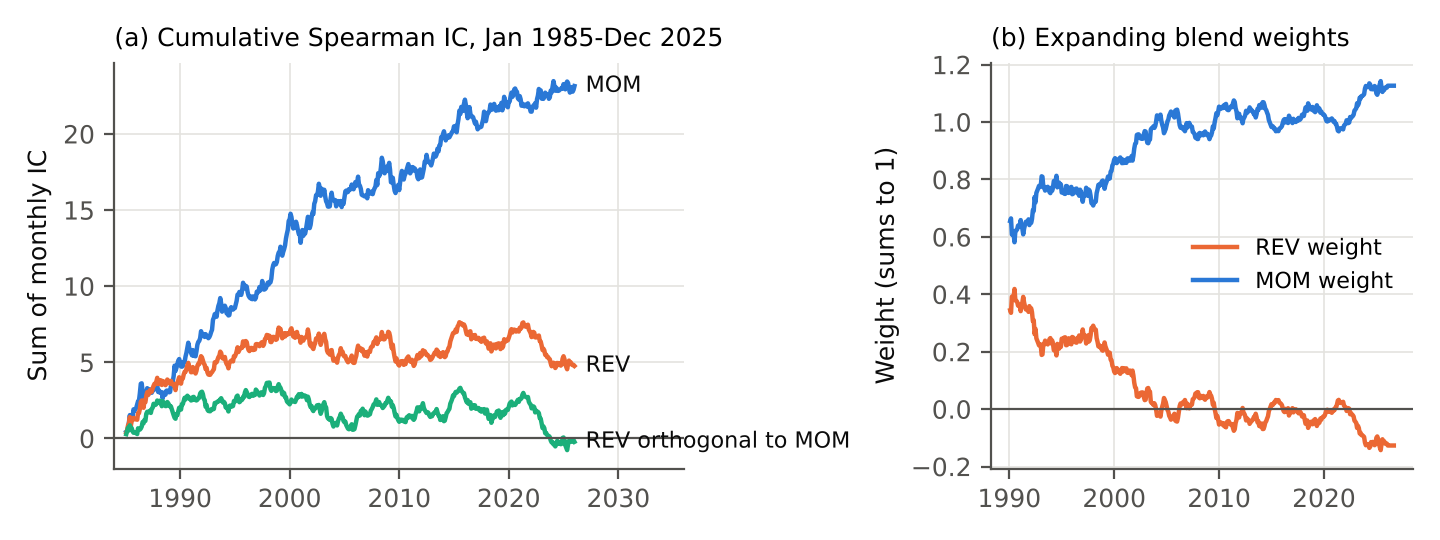

## 5. Portfolio construction

Grinold–Kahn alphas α = IC · ω · z (demeaned, so dollar neutral). Mean-variance holdings h = Σ⁻¹α/(2λ) with
Σ h = 0 and |hₙ| ≤ 10% of gross; λ is reset every month so ex-ante active risk is exactly 5% a year. Σ is an EWMA
covariance of the 49 industries (30-month half-life, the HW1 choice; 60-month minimum), shrunk 50% toward its
diagonal because the unshrunk model realized about 10% risk with roughly 4× gross. ω is each industry's volatility
residual to the equal-weighted industry average.

## 6. Risk

In [7]:
risk = pd.read_csv(PT / "portfolio_risk_summary.csv")
risk_mv = risk[risk.method == "mv"].copy()
risk_tab = pd.DataFrame({
    "Strategy": risk_mv.strategy.map(NAMES),
    "First month": risk_mv.first_month, "Months": risk_mv.months,
    "Ex-ante risk": risk_mv.exante_active_risk_ann_mean,
    "Realized vol": risk_mv.realized_active_vol_ann,
    "Realized/target": risk_mv.realized_to_target_ratio,
    "Median lambda": risk_mv.lambda_median, "lambda p10": risk_mv.lambda_p10, "lambda p90": risk_mv.lambda_p90,
    "Mean gross": risk_mv.gross_exposure_mean})
risk_tab.to_csv(TAB / "T3_risk.csv", index=False)
display(risk_tab.round(3))
for _, r in risk_mv.iterrows():
    NUM[f"risk_realized_{r.strategy}"] = float(r.realized_active_vol_ann)
    NUM[f"risk_ratio_{r.strategy}"] = float(r.realized_to_target_ratio)
    NUM[f"lambda_median_{r.strategy}"] = float(r.lambda_median)
    NUM[f"lambda_p10_{r.strategy}"] = float(r.lambda_p10); NUM[f"lambda_p90_{r.strategy}"] = float(r.lambda_p90)
    NUM[f"gross_{r.strategy}"] = float(r.gross_exposure_mean)

,Strategy,First month,Months,Ex-ante risk,Realized vol,Realized/target,Median lambda,lambda p10,lambda p90,Mean gross
0,MOM,1974-06-30,627,0.05,0.062,1.244,3.778,3.276,4.304,1.197
2,REV,1990-01-31,432,0.05,0.048,0.956,1.213,0.719,2.496,1.496
4,REV orthogonal to MOM,1990-01-31,432,0.05,0.043,0.858,0.335,0.143,1.115,1.525
6,Blend,1995-01-31,372,0.05,0.066,1.323,2.324,1.933,3.226,1.219


**Interpretation.** Ex-ante risk is 5% by construction. The blend realizes 6.6% (1.32× target) and MOM 6.2%, mainly because of the 2009 momentum crash. Median λ for the blend is 2.32 (10th–90th percentile 1.93–3.23).

## 7. Portfolio performance

Gross return in month t+1 is h(t)·r(t+1). Turnover is measured against last month's weights after they drift with
returns; the one-way cost is charged on the next month's return. The `common` window (formation months Jan 1995–Dec 2025)
is the only window in which all four strategies trade.

In [8]:
perf = pd.read_csv(PT / "performance_by_window.csv")
srm = pd.read_csv(PT / "strategy_returns_by_month.csv", parse_dates=["month", "return_month"])
srm = srm[srm.method == "mv"]

def be_cost(g):
    return g.gross_return.mean() / g.turnover.mean() * 1e4  # bp, one-way

rows = []
for s in ["mom", "rev", "rev_orth", "blend"]:
    p = perf[(perf.strategy == s) & (perf.method == "mv") & (perf.window == "common")].iloc[0]
    g = srm[(srm.strategy == s) & srm.month.between("1995-01-31", "2025-12-31")]
    rows.append({"Strategy": NAMES[s], "Gross return": p.ann_return_gross, "Vol": p.ann_vol_gross,
                 "Gross Sharpe": p.sharpe_gross, "Monthly turnover": p.avg_monthly_turnover,
                 "Net Sharpe 10bp": p.sharpe_net_10bps, "Net Sharpe 20bp": p.sharpe_net_20bps,
                 "Net Sharpe 30bp": p.sharpe_net_30bps, "Net return 20bp": p.ann_return_net_20bps,
                 "Max DD 20bp": p.max_drawdown_net_20bps, "Break-even cost (bp)": be_cost(g)})
    for k, v in rows[-1].items():
        if k != "Strategy":
            NUM[f"perf_common_{s}_{k}"] = float(v)
perf_tab = pd.DataFrame(rows)
perf_tab.to_csv(TAB / "T4_performance_common.csv", index=False)
display(perf_tab.round(3))

,Strategy,Gross return,Vol,Gross Sharpe,Monthly turnover,Net Sharpe 10bp,Net Sharpe 20bp,Net Sharpe 30bp,Net return 20bp,Max DD 20bp,Break-even cost (bp)
0,MOM,0.039,0.066,0.586,0.513,0.493,0.400,0.307,0.027,-0.202,63.110
1,REV,0.002,0.050,0.044,1.739,-0.375,-0.795,-1.214,-0.040,-0.720,1.059
2,REV orthogonal to MOM,-0.003,0.044,-0.077,1.819,-0.573,-1.068,-1.562,-0.047,-0.777,-1.549
3,Blend,0.032,0.066,0.485,0.579,0.380,0.275,0.170,0.018,-0.230,46.112


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(7.2, 2.7), gridspec_kw={"width_ratios": [1.35, 1]})
for s in ["mom", "blend", "rev", "rev_orth"]:
    g = srm[(srm.strategy == s) & srm.month.between("1995-01-31", "2025-12-31")].set_index("return_month")
    w = (1 + g.net_return_20bps).cumprod()
    ax[0].plot(w.index, w.values, color=COLORS[s], lw=1.6)
    ax[0].annotate(NAMES[s] if s != "rev_orth" else "REV orth.", (w.index[-1], w.values[-1]),
                   xytext=(4, 0), textcoords="offset points", fontsize=8, color=INK, va="center")
ax[0].set_yscale("log")
ax[0].yaxis.set_major_locator(matplotlib.ticker.FixedLocator([0.25, 0.5, 1, 2]))
ax[0].yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"${v:g}"))
ax[0].yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax[0].set_title("(a) Growth of $1, net of 20 bp, Feb 1995-Jan 2026", fontsize=9, loc="left")
ax[0].set_ylabel("Value of $1 (log scale)")
ax[0].set_xlim(right=pd.Timestamp("2032-06-01"))
ax[0].axhline(1, color=INK2, lw=0.8)
g = srm[(srm.strategy == "blend")].set_index("return_month").net_return_20bps
from src.backtest import drawdown_series
dd = drawdown_series(g)
ax[1].fill_between(dd.index, dd.values * 100, 0, color=YELLOW, alpha=0.85, lw=0)
ax[1].set_title("(b) Blend drawdown, net of 20 bp", fontsize=9, loc="left")
ax[1].set_ylabel("Drawdown (%)")
for a in ax:
    a.xaxis.set_major_locator(mdates.YearLocator(10)); a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
fig.savefig(FIG / "fig2_cumulative_drawdown.pdf"); fig.savefig(FIG / "fig2_cumulative_drawdown.png", dpi=200)
plt.close(fig)
NUM["blend_maxdd_full"] = float(dd.min()); NUM["blend_maxdd_date"] = str(dd.idxmin().date())

**Figure 2. (a) Growth of $1, net of 20 bp, February 1995–January 2026, log scale. (b) Blend drawdown, net of 20 bp.**

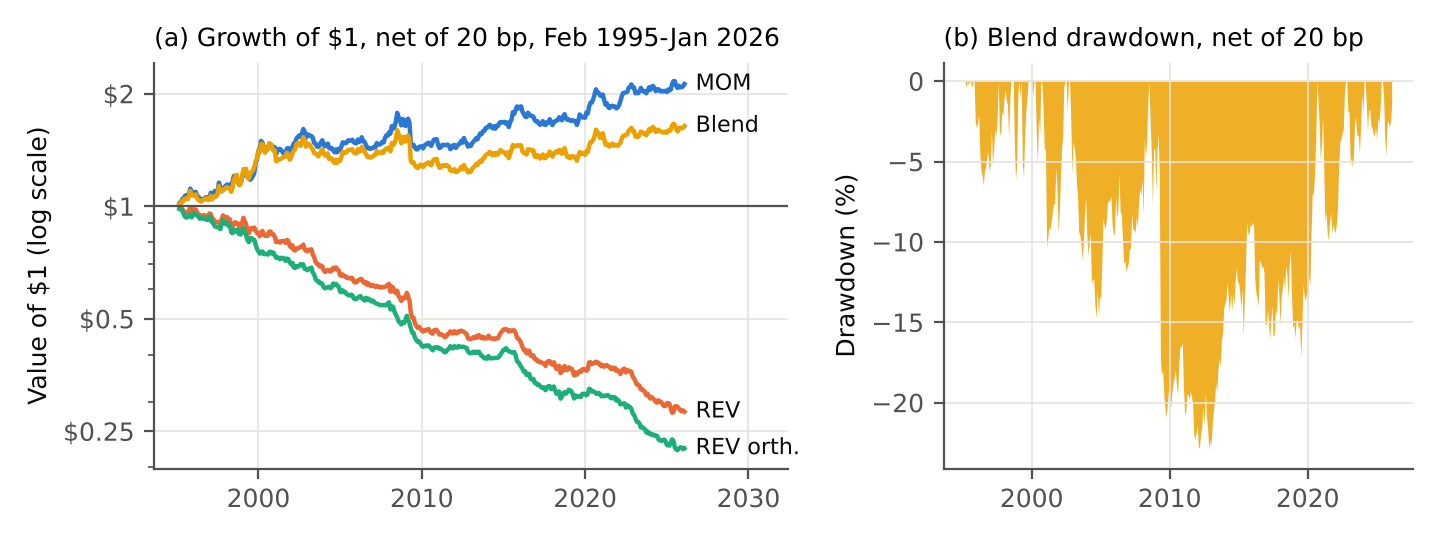

## 8. Turnover and transaction costs

From the table in Section 7: REV books trade about 174% of capital a month (182% for REV orthogonal) against 51% for MOM
and 58% for the blend. REV's break-even one-way cost is about 1 bp, so at 20 bp it loses 4.0% a year (net Sharpe −0.80).
Industry revision ranks change too much month to month to be traded profitably. The cost level at which the blend's
**6-factor** alpha disappears is in Section 9.3, because it needs the factor data loaded in Section 9.

## 9. Factor attribution: is the alpha new, or is it momentum?

Net returns (20 bp) regressed on FF5, FF5+UMD (primary) and FF5+UMD+short-term reversal, with NW(6) t-statistics.
Each return month t+1 is matched to factor returns of month t+1.

In [10]:
fr = pd.read_csv(PT / "factor_regressions.csv")
fr = fr[fr.method == "mv"]
rows = []
for s in ["mom", "rev", "rev_orth", "blend"]:
    for w in ["common", "post_2010", "recent_18m"]:
        g = fr[(fr.strategy == s) & (fr.window == w)].set_index("spec")
        a, b, c = g.loc["ff5"], g.loc["ff5_umd"], g.loc["ff5_umd_strev"]
        rows.append({"Strategy": NAMES[s], "Window": w, "Months": int(b.n),
                     "FF5 alpha": a.alpha_ann, "FF5 t": a.alpha_t,
                     "FF5+UMD alpha": b.alpha_ann, "FF5+UMD t": b.alpha_t,
                     "UMD beta": b.beta_UMD, "UMD t": b.t_UMD, "R2 FF5": a.r2, "R2 FF5+UMD": b.r2,
                     "+STREV alpha": c.alpha_ann, "+STREV t": c.alpha_t,
                     "Verdict": "low power" if b.n < config.CRITERION_MIN_MONTHS
                     else ("pass" if (b.alpha_ann > 0 and b.alpha_t >= 2) else "fail")})
        for k in ["FF5 alpha", "FF5 t", "FF5+UMD alpha", "FF5+UMD t", "UMD beta", "UMD t", "R2 FF5", "R2 FF5+UMD",
                  "+STREV alpha", "+STREV t", "Months"]:
            NUM[f"attr_{s}_{w}_{k}"] = float(rows[-1][k])
attr_tab = pd.DataFrame(rows)
attr_tab.to_csv(TAB / "T5_attribution.csv", index=False)
display(attr_tab.round(3))

,Strategy,Window,Months,FF5 alpha,FF5 t,FF5+UMD alpha,FF5+UMD t,UMD beta,UMD t,R2 FF5,R2 FF5+UMD,+STREV alpha,+STREV t,Verdict
0,MOM,common,372,0.033,2.835,0.012,1.549,0.290,16.937,0.108,0.559,0.012,1.532,fail
1,MOM,post_2010,199,0.022,1.684,0.007,0.642,0.275,11.075,0.159,0.467,0.008,0.688,fail
2,MOM,recent_18m,17,-0.040,-0.636,-0.005,-0.118,0.230,3.534,0.371,0.582,0.008,0.216,low power
3,REV,common,372,-0.035,-4.491,-0.045,-5.828,0.134,7.588,0.077,0.249,-0.045,-5.783,fail
4,REV,post_2010,192,-0.030,-2.717,-0.035,-3.023,0.087,3.177,0.082,0.127,-0.036,-3.120,fail
5,REV,recent_18m,10,-0.103,-1.705,-0.056,-2.830,-0.242,-2.599,0.561,0.753,-0.046,-2.918,low power
6,REV orthogonal to MOM,common,372,-0.042,-5.108,-0.046,-5.502,0.066,4.341,0.036,0.089,-0.046,-5.486,fail
7,REV orthogonal to MOM,post_2010,192,-0.033,-2.798,-0.037,-2.944,0.064,2.679,0.029,0.058,-0.037,-2.989,fail
8,REV orthogonal to MOM,recent_18m,10,0.018,0.267,-0.043,-2.573,0.311,3.613,0.483,0.784,-0.051,-3.151,low power
9,Blend,common,372,0.024,2.213,0.002,0.361,0.299,20.392,0.104,0.588,0.002,0.347,fail


**Interpretation.** Against FF5 the blend shows 2.4% a year (t = 2.21). Adding UMD cuts it to 0.2% (t = 0.36), with a UMD loading of 0.30 (t = 20.4); after 2010 it is −0.0% (t = −0.02). REV and REV orthogonal have significantly negative net alphas. **The blend's apparent alpha is momentum exposure.**

### 9.1 Independent check of the key regression

We re-estimate the blend's FF5 and FF5+UMD alphas with statsmodels directly (not through `src/attribution.py`).

In [11]:
ff = pd.read_parquet(config.DATA_RAW / "kf_ff5.parquet").merge(pd.read_parquet(config.DATA_RAW / "kf_umd.parquet"), on="date")
ff["date"] = pd.to_datetime(ff["date"]) + pd.offsets.MonthEnd(0)
chk = []
for s, w0, w1 in [("blend", "1995-01-31", "2025-12-31"), ("blend", "2010-01-31", "2026-08-31"),
                  ("mom", "1995-01-31", "2025-12-31")]:
    g = srm[(srm.strategy == s) & srm.month.between(w0, w1)][["return_month", "net_return_20bps"]]
    d = g.merge(ff, left_on="return_month", right_on="date", how="inner").dropna()
    for spec, cols in [("ff5", ["Mkt-RF", "SMB", "HML", "RMW", "CMA"]), ("ff5_umd", ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "UMD"])]:
        m = sm.OLS(d.net_return_20bps, sm.add_constant(d[cols])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
        chk.append({"strategy": s, "start": w0, "spec": spec, "n": len(d), "alpha_ann": 12 * m.params["const"],
                    "t": m.tvalues["const"]})
chk = pd.DataFrame(chk)
display(chk.round(4))
pipe = {("blend", "1995-01-31"): "common", ("blend", "2010-01-31"): "post_2010", ("mom", "1995-01-31"): "common"}
maxdiff = 0.0
for _, r in chk.iterrows():
    p = fr[(fr.strategy == r.strategy) & (fr.window == pipe[(r.strategy, r.start)]) & (fr.spec == r.spec)].iloc[0]
    maxdiff = max(maxdiff, abs(p.alpha_t - r.t), abs(p.alpha_ann - r.alpha_ann))
print("max |pipeline - independent| over alphas and t-stats:", maxdiff)
assert maxdiff < 1e-6
NUM["independent_check_maxdiff"] = float(maxdiff)

,strategy,start,spec,n,alpha_ann,t
0,blend,1995-01-31,ff5,372,0.0238,2.2134
1,blend,1995-01-31,ff5_umd,372,0.0024,0.3610
2,blend,2010-01-31,ff5,192,0.0155,1.2784
3,blend,2010-01-31,ff5_umd,192,-0.0002,-0.0195
4,mom,1995-01-31,ff5,372,0.0326,2.8351
5,mom,1995-01-31,ff5_umd,372,0.0119,1.5489


max |pipeline - independent| over alphas and t-stats: 4.440892098500626e-16


### 9.2 Figure 3 — alpha before and after controlling for UMD

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 2.5))
items = [("mom", "common"), ("mom", "post_2010"), ("blend", "common"), ("blend", "post_2010"),
         ("rev", "common"), ("rev", "post_2010")]
xlab = {"common": "1995-2025", "post_2010": "post-2010"}
for i, (s, w) in enumerate(items):
    for j, (spec, col, off) in enumerate([("ff5", INK2, -0.15), ("ff5_umd", BLUE, 0.15)]):
        g = fr[(fr.strategy == s) & (fr.window == w) & (fr.spec == spec)].iloc[0]
        se = g.alpha_ann / g.alpha_t if g.alpha_t != 0 else np.nan
        ax.errorbar(i + off, 100 * g.alpha_ann, yerr=196 * abs(se), fmt="o", color=col, ms=5, capsize=2, lw=1.2,
                    label=("FF5 alpha" if spec == "ff5" else "FF5+UMD alpha") if i == 0 else None)
ax.axhline(0, color=INK2, lw=0.8)
ax.set_xticks(range(len(items)))
ax.set_xticklabels([f"{NAMES[s]}\n{xlab[w]}" for s, w in items], fontsize=8)
ax.set_ylabel("Annual alpha, net 20 bp (%)")
ax.set_title("Net alpha with 95% Newey-West intervals: adding UMD removes the MOM and Blend alpha", fontsize=9, loc="left")
ax.legend(loc="lower left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(FIG / "fig3_alpha_ff5_vs_umd.pdf"); fig.savefig(FIG / "fig3_alpha_ff5_vs_umd.png", dpi=200)
plt.close(fig)

**Figure 3. Annual net alpha (20 bp) with 95% Newey–West intervals against FF5 (grey) and FF5+UMD (blue).**

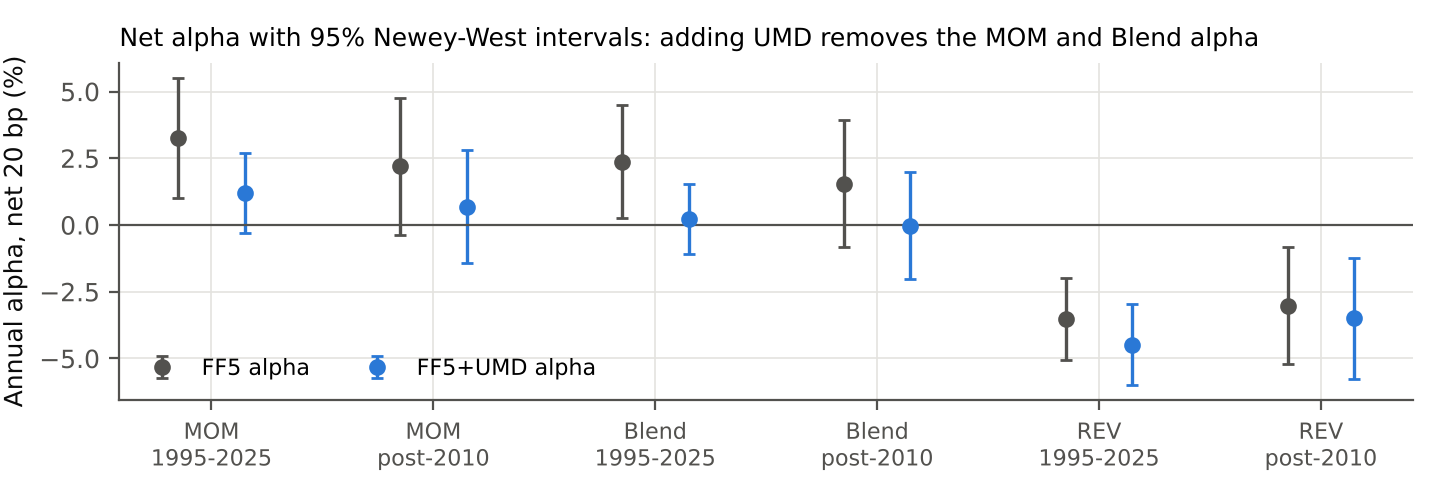

### 9.3 Gross alpha and the cost that erases it

Gross returns and returns net of 10, 20 and 30 bp regressed on FF5+UMD. Dividing the monthly gross alpha by mean monthly
turnover gives the one-way cost at which the 6-factor alpha is exactly zero. The pre-registered criterion uses 20 bp.

In [12]:
cols6 = ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "UMD"]
cost_rows = []
for w, (w0, w1) in {"common": ("1995-01-31", "2025-12-31"), "post_2010": ("2010-01-31", "2026-08-31")}.items():
    for s in ["mom", "blend", "rev", "rev_orth"]:
        gx = srm[(srm.strategy == s) & srm.month.between(w0, w1)].merge(ff, left_on="return_month", right_on="date")
        r = {"Strategy": NAMES[s], "Window": w, "Months": len(gx)}
        for lab, col in [("gross", "gross_return"), ("net 10bp", "net_return_10bps"), ("net 20bp", "net_return_20bps"),
                         ("net 30bp", "net_return_30bps")]:
            m = sm.OLS(gx[col], sm.add_constant(gx[cols6])).fit(cov_type="HAC", cov_kwds={"maxlags": 6})
            r[f"alpha {lab}"] = 12 * m.params["const"]; r[f"t {lab}"] = m.tvalues["const"]
            NUM[f"alpha6_{lab.replace(' ', '')}_{s}_{w}"] = float(r[f"alpha {lab}"])
            NUM[f"alpha6_t_{lab.replace(' ', '')}_{s}_{w}"] = float(r[f"t {lab}"])
        r["Zero-alpha cost (bp)"] = r["alpha gross"] / 12 / gx.turnover.mean() * 1e4
        NUM[f"alpha6_breakeven_bp_{s}_{w}"] = float(r["Zero-alpha cost (bp)"])
        cost_rows.append(r)
cost_tab = pd.DataFrame(cost_rows)
cost_tab.to_csv(TAB / "T9_alpha_by_cost.csv", index=False)
display(cost_tab.round(3))

,Strategy,Window,Months,alpha gross,t gross,alpha net 10bp,t net 10bp,alpha net 20bp,t net 20bp,alpha net 30bp,t net 30bp,Zero-alpha cost (bp)
0,MOM,common,372,0.024,3.181,0.018,2.363,0.012,1.549,0.006,0.741,39.366
1,Blend,common,372,0.016,2.436,0.009,1.399,0.002,0.361,-0.005,-0.675,23.426
2,REV,common,372,-0.003,-0.387,-0.024,-3.103,-0.045,-5.828,-0.066,-8.542,-1.437
3,REV orthogonal to MOM,common,372,-0.003,-0.302,-0.024,-2.895,-0.046,-5.502,-0.068,-8.105,-1.175
4,MOM,post_2010,199,0.019,1.764,0.013,1.200,0.007,0.642,0.001,0.090,31.790
5,Blend,post_2010,192,0.013,1.263,0.006,0.619,-0.000,-0.020,-0.007,-0.652,19.757
6,REV,post_2010,192,0.008,0.678,-0.014,-1.178,-0.035,-3.023,-0.056,-4.843,3.661
7,REV orthogonal to MOM,post_2010,192,0.008,0.671,-0.014,-1.138,-0.037,-2.944,-0.059,-4.736,3.730


**Interpretation.** The blend's gross 6-factor alpha (1.6%, t = 2.44) is smaller than MOM's alone (2.4%, t = 3.18): revisions dilute rather than add. It is fully consumed at 23 bp and not significant at 10 bp (t = 1.40) or after 2010.

## 10. Horizon and regime analysis

Required windows: full sample, post-2010, and the most recent 18 signal months (March 2025–August 2026). REV is missing
after December 2025, so the REV-based strategies have only 10 return months in the recent window. Regressions on fewer
than 36 months are labeled **LOW POWER** and not used for the verdict.

In [14]:
rows = []
for s in ["mom", "blend", "rev", "rev_orth"]:
    for w in ["full", "common", "post_2010", "recent_18m"]:
        p = perf[(perf.strategy == s) & (perf.method == "mv") & (perf.window == w)].iloc[0]
        f6 = fr[(fr.strategy == s) & (fr.window == w) & (fr.spec == "ff5_umd")].iloc[0]
        rows.append({"Strategy": NAMES[s], "Window": w,
                     "Return months": f"{p.first_return_month[:7]} to {p.last_return_month[:7]}",
                     "Months": int(p.months_with_returns), "Net return 20bp": p.ann_return_net_20bps,
                     "Net Sharpe 20bp": p.sharpe_net_20bps, "FF5+UMD alpha": f6.alpha_ann, "t": f6.alpha_t,
                     "Power": "LOW POWER" if f6.n < config.CRITERION_MIN_MONTHS else ""})
        NUM[f"hor_{s}_{w}_netret"] = float(p.ann_return_net_20bps); NUM[f"hor_{s}_{w}_netsr"] = float(p.sharpe_net_20bps)
        NUM[f"hor_{s}_{w}_months"] = int(p.months_with_returns)
hor_tab = pd.DataFrame(rows)
hor_tab.to_csv(TAB / "T6_horizons.csv", index=False)
display(hor_tab.round(3))

,Strategy,Window,Return months,Months,Net return 20bp,Net Sharpe 20bp,FF5+UMD alpha,t,Power
0,MOM,full,1974-07 to 2026-08,626,0.021,0.345,0.004,0.695,
1,MOM,common,1995-02 to 2026-01,372,0.027,0.400,0.012,1.549,
2,MOM,post_2010,2010-02 to 2026-08,199,0.025,0.444,0.007,0.642,
3,MOM,recent_18m,2025-04 to 2026-08,17,0.019,0.277,-0.005,-0.118,LOW POWER
4,Blend,full,1995-02 to 2026-01,372,0.018,0.275,0.002,0.361,
5,Blend,common,1995-02 to 2026-01,372,0.018,0.275,0.002,0.361,
6,Blend,post_2010,2010-02 to 2026-01,192,0.017,0.323,-0.000,-0.020,
7,Blend,recent_18m,2025-04 to 2026-01,10,0.028,0.520,0.033,3.396,LOW POWER
8,REV,full,1990-02 to 2026-01,432,-0.038,-0.795,-0.044,-6.127,
9,REV,common,1995-02 to 2026-01,372,-0.040,-0.795,-0.045,-5.828,


### 10.1 Stress years (2009, 2020) and rolling 36-month alpha

In [15]:
stress = pd.read_csv(PT / "stress_2009_2020.csv", parse_dates=["return_month"])
st = []
for yr in [2009, 2020]:
    g = stress[stress.return_month.dt.year == yr]
    r = {"Year": yr}
    for c in ["blend_net", "mom_net", "rev_net", "rev_orth_net", "UMD"]:
        r[c] = (1 + g[c]).prod() - 1
        NUM[f"stress_{yr}_{c}"] = float(r[c])
    st.append(r)
apr = stress[stress.return_month == "2009-04-30"].iloc[0]
for c in ["blend_net", "mom_net", "rev_net", "UMD"]:
    NUM[f"stress_2009apr_{c}"] = float(apr[c])
st_tab = pd.DataFrame(st); st_tab.to_csv(TAB / "T7_stress.csv", index=False); display(st_tab.round(3))

roll = pd.read_csv(PT / "rolling_alpha_blend.csv")
NUM["roll_n"] = len(roll); NUM["roll_mean"] = float(roll.alpha_ann.mean())
NUM["roll_min"] = float(roll.alpha_ann.min()); NUM["roll_max"] = float(roll.alpha_ann.max())
NUM["roll_share_t_ge2"] = float((roll.alpha_t >= 2).mean()); NUM["roll_share_t_le_m2"] = float((roll.alpha_t <= -2).mean())
print({k: NUM[k] for k in NUM if k.startswith("roll")})

,Year,blend_net,mom_net,rev_net,rev_orth_net,UMD
0,2009,-0.133,-0.118,-0.183,-0.147,-0.528
1,2020,0.123,0.143,0.020,-0.013,-0.009


{'roll_n': 337, 'roll_mean': -0.0013611564089837116, 'roll_min': -0.0636636211884182, 'roll_max': 0.0532082434435929, 'roll_share_t_ge2': 0.05934718100890208, 'roll_share_t_le_m2': 0.050445103857566766}


**Rolling 36-month FF5+UMD alpha of the blend, net of 20 bp (pipeline output).**

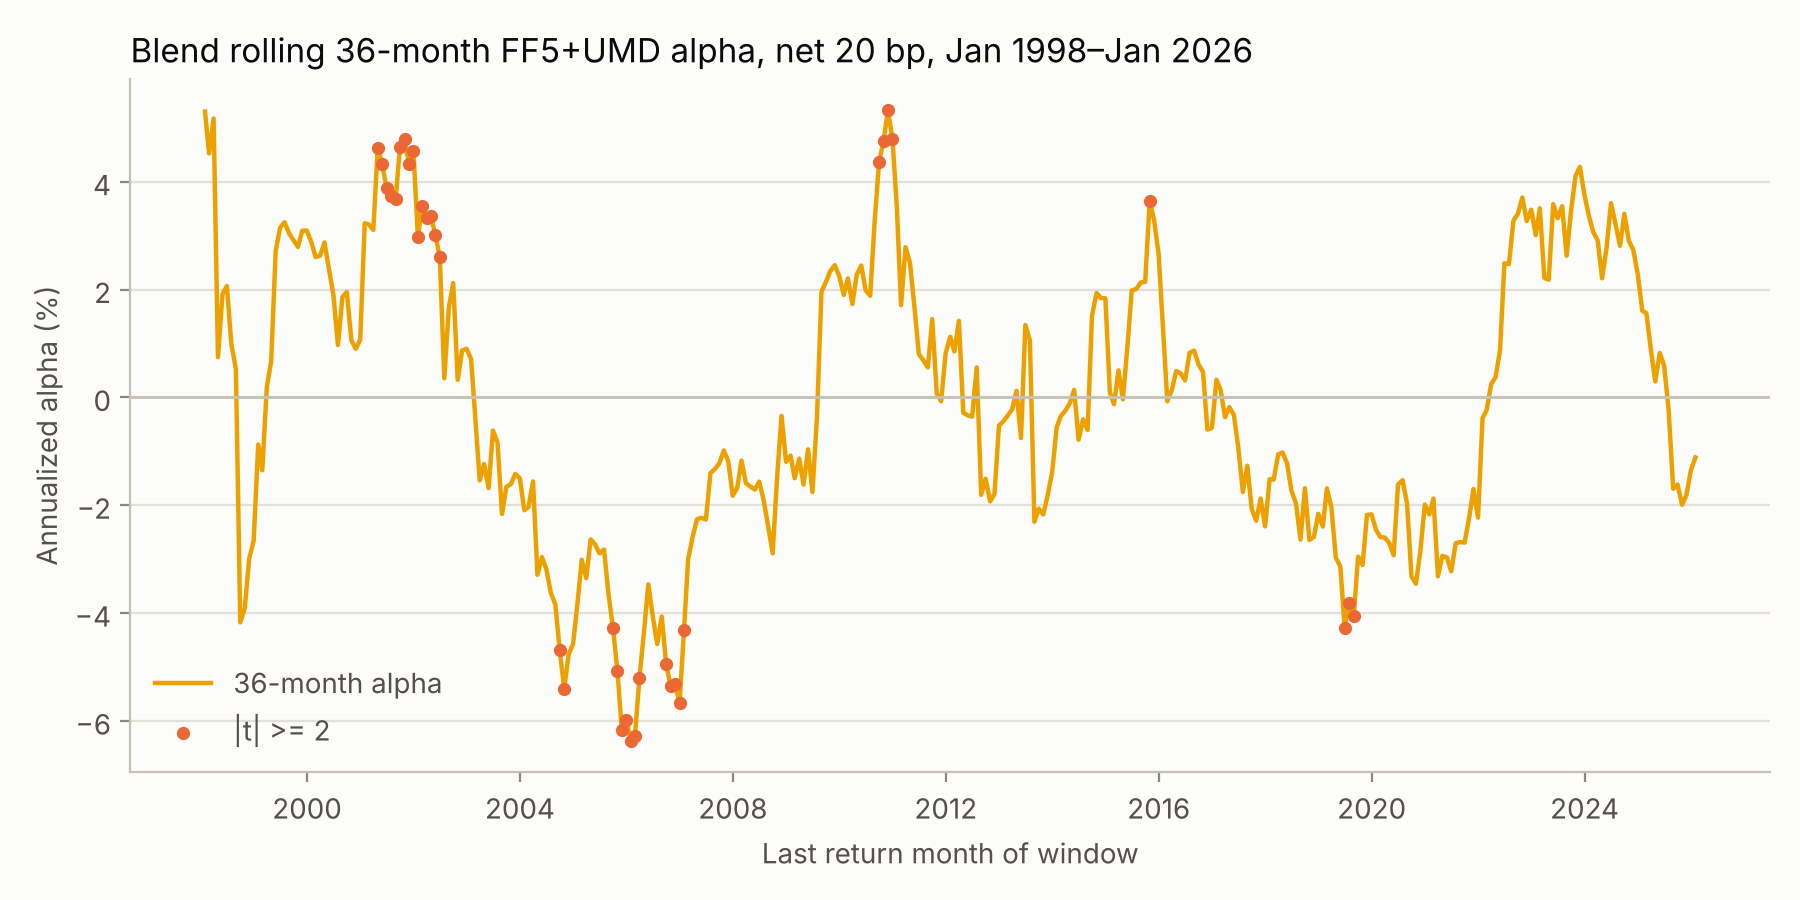

**Interpretation.** The blend's recent t = 3.40 comes from 10 observations and carries no information. In 2009 the blend lost 13.3% (UMD −52.8%) and REV did not hedge the crash (−18.3%). The rolling alpha averages −0.1% a year with no persistent positive regime.

## 11. Robustness

One design choice changes at a time around the base case; each row reruns signals → IC blend → holdings → backtest for
the blend and is scored on formation months Jan 1995–Dec 2025. Rows marked (*) need WRDS stock-level files; a teammate
ran them on a different cleaned CRSP panel, so they are shown separately and flagged.

In [16]:
grid = pd.read_csv(PT / "robustness_grid.csv")
extra = pd.read_csv(PT / "robustness_grid_teammate_raw_rows.csv")
labels_g = {"base": "Base case", "cost_bps=10": "Costs 10 bp", "cost_bps=30": "Costs 30 bp",
            "mom_lookback=6": "Momentum lookback 6m", "mom_lookback=9": "Momentum lookback 9m",
            "rev_measure=consensus_change": "REV = consensus change", "cov_halflife=18": "Cov. half-life 18m",
            "cov_halflife=60": "Cov. half-life 60m", "target_active_risk=0.03": "Risk target 3%",
            "target_active_risk=0.08": "Risk target 8%", "neutrality=dollar_beta": "Dollar + beta neutral",
            "min_analysts=1": "Min analysts 1 (*)", "min_analysts=5": "Min analysts 5 (*)",
            "industry_set=30": "30 industries (*)"}
g = pd.concat([grid[grid.status == "ok"], extra], ignore_index=True)
g = g[g.id.isin(labels_g)]
rob_tab = pd.DataFrame({"Change from base": g.id.map(labels_g), "Gross Sharpe": g.sharpe_gross,
                        "Net Sharpe": g.sharpe_net, "Net Sharpe post-2010": g.sharpe_net_post_2010,
                        "Monthly turnover": g.avg_monthly_turnover, "FF5+UMD alpha": g.alpha_ann_ff5_umd,
                        "t": g.alpha_t_ff5_umd})
rob_tab.to_csv(TAB / "T8_robustness.csv", index=False)
display(rob_tab.round(3))
NUM["rob_max_t"] = float(rob_tab.t.max()); NUM["rob_max_t_row"] = rob_tab.loc[rob_tab.t.idxmax(), "Change from base"]
NUM["rob_min_t"] = float(rob_tab.t.min()); NUM["rob_max_netsr"] = float(rob_tab["Net Sharpe"].max())
NUM["rob_n_rows"] = len(rob_tab)
for _, r in g.iterrows():
    NUM[f"rob_{r.id}_netsr"] = float(r.sharpe_net); NUM[f"rob_{r.id}_t"] = float(r.alpha_t_ff5_umd)
    NUM[f"rob_{r.id}_alpha"] = float(r.alpha_ann_ff5_umd); NUM[f"rob_{r.id}_turnover"] = float(r.avg_monthly_turnover)
heat = grid[grid.id.str.startswith("heatmap") | grid.id.isin(["base", "mom_lookback=6", "mom_lookback=9", "cov_halflife=18", "cov_halflife=60"])]
NUM["heat_netsr_min"] = float(heat.sharpe_net.min()); NUM["heat_netsr_max"] = float(heat.sharpe_net.max())

,Change from base,Gross Sharpe,Net Sharpe,Net Sharpe post-2010,Monthly turnover,FF5+UMD alpha,t
0,Base case,0.485,0.275,0.323,0.579,0.002,0.361
1,Costs 10 bp,0.485,0.380,0.446,0.579,0.009,1.399
2,Costs 30 bp,0.485,0.170,0.201,0.579,-0.005,-0.675
3,Momentum lookback 6m,0.146,-0.398,-0.155,1.298,-0.031,-3.892
4,Momentum lookback 9m,0.325,0.041,0.109,0.750,-0.013,-1.829
5,REV = consensus change,0.385,0.146,0.203,0.623,-0.006,-0.823
6,Cov. half-life 18m,0.495,0.278,0.337,0.588,0.003,0.380
7,Cov. half-life 60m,0.454,0.258,0.306,0.574,0.001,0.175
8,Risk target 3%,0.485,0.275,0.323,0.348,0.001,0.361
9,Risk target 8%,0.485,0.274,0.323,0.928,0.004,0.359


**Net Sharpe (20 bp) of the blend over momentum lookback × covariance half-life (pipeline output).**

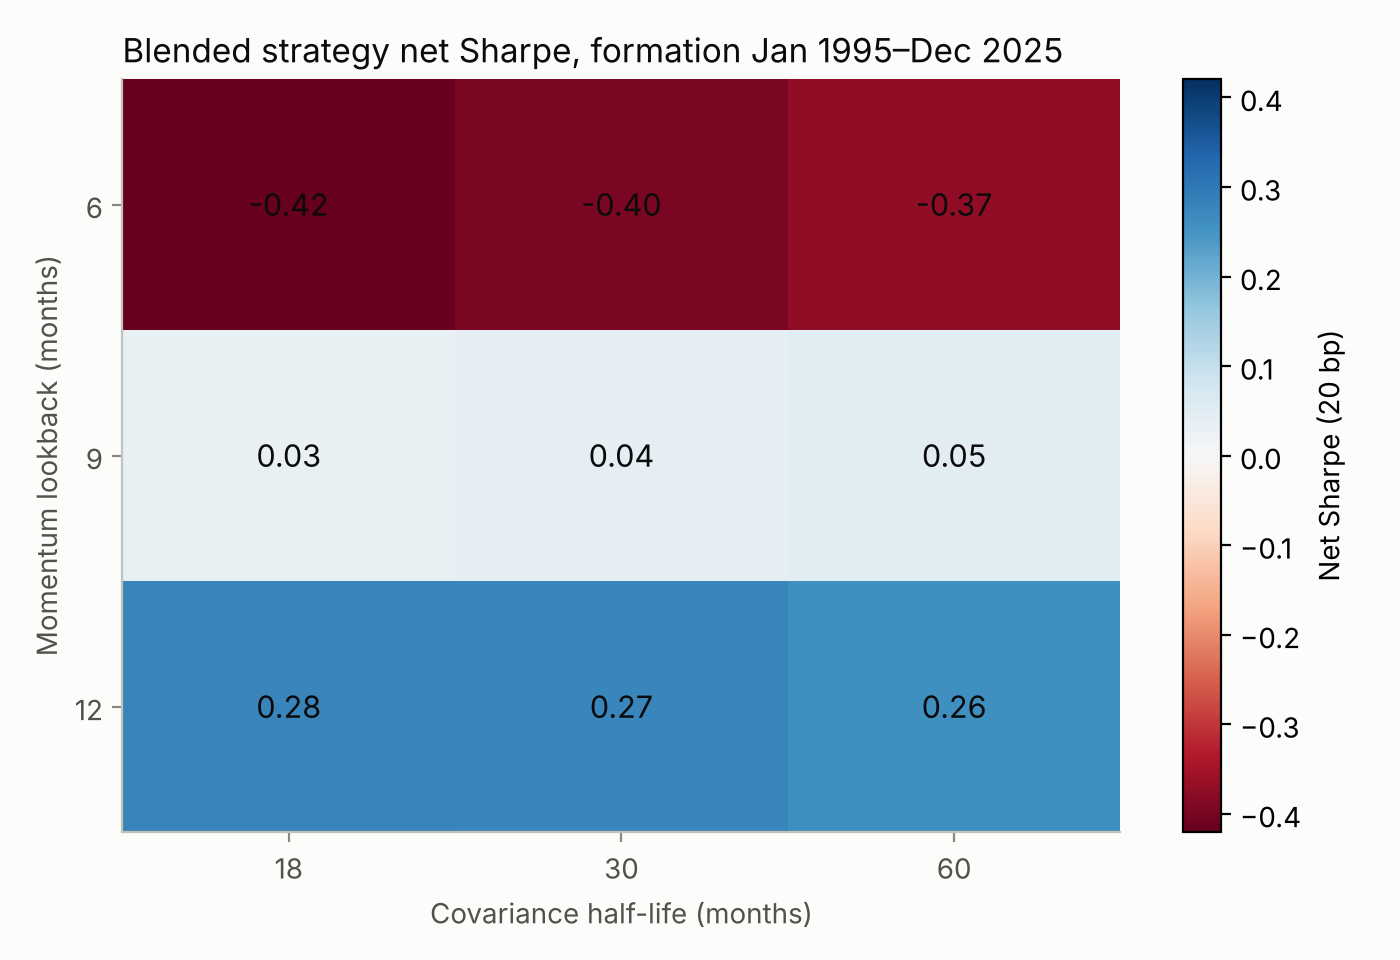

**Interpretation.** No reasonable specification reverses the conclusion: the highest FF5+UMD t in the grid is 1.40 (10 bp costs) and the highest net Sharpe 0.38.

## 12. Final decision

The pre-registered criterion requires a positive FF5+UMD net alpha with t ≥ 2. No strategy meets it in the 1995–2025 or
post-2010 window, and no robustness row meets it. The only window with t ≥ 2 is the blend's 10-month recent window
(low power).

**Do not implement the analyst-revision overlay in its current form.** Industry revisions mostly reflect the same news as
industry momentum (average cross-sectional correlation 0.31, zero orthogonal IC), the small independent part they had in
the late 1980s disappeared, and their month-to-month rank changes make them expensive to trade.

In [17]:
crit = attr_tab[attr_tab.Window.isin(["common", "post_2010"])][["Strategy", "Window", "FF5+UMD alpha", "FF5+UMD t", "Verdict"]]
display(crit.round(3))
assert (crit.Verdict == "fail").all()
NUM["verdict"] = "do not implement"

,Strategy,Window,FF5+UMD alpha,FF5+UMD t,Verdict
0,MOM,common,0.012,1.549,fail
1,MOM,post_2010,0.007,0.642,fail
3,REV,common,-0.045,-5.828,fail
4,REV,post_2010,-0.035,-3.023,fail
6,REV orthogonal to MOM,common,-0.046,-5.502,fail
7,REV orthogonal to MOM,post_2010,-0.037,-2.944,fail
9,Blend,common,0.002,0.361,fail
10,Blend,post_2010,-0.000,-0.020,fail


---
*Appendix: export of the tables and numbers used in the final report (writes to `tables/`).*

In [18]:
def pct(x, d=1):
    return f"{100 * x:.{d}f}"

def f2(x, d=2):
    return f"{x:.{d}f}".replace("-", "$-$") if pd.notna(x) else "--"

def p1(x, d=1):
    return pct(x, d).replace("-", "$-$") if pd.notna(x) else "--"

def write(name, header, body, colspec, notes=None):
    lines = [r"\begin{tabular}{" + colspec + "}", r"\toprule", header + r" \\", r"\midrule"]
    lines += [b + r" \\" for b in body]
    lines += [r"\bottomrule", r"\end{tabular}"]
    (TAB / f"{name}.tex").write_text("\n".join(lines) + "\n")

# T1 IC
body = []
for _, r in ic_tab[ic_tab.Signal != "REV (consensus change)"].iterrows():
    body.append(f"{r.Signal} & {f2(r['IC 1985-2025'],3)} & {f2(r['NW t 1985-2025'])} & {f2(r['IC post-2010'],3)} & "
                f"{f2(r['NW t post-2010'])} & {f2(r['IC recent 18m'],3)} & {int(r['months recent 18m'])}")
write("T1_ic_summary", r"Signal & IC & NW $t$ & IC & NW $t$ & IC & Months \\ & \multicolumn{2}{c}{1985--2025} & \multicolumn{2}{c}{Post-2010} & \multicolumn{2}{c}{Recent 18m (low power)}",
      body, "lrrrrrr")

# T2 IC subperiods
body = [f"{r.Signal} & " + " & ".join(f"{f2(r[f'IC {b}'],3)} ({f2(r[f'NW t {b}'])})" for b in blocks) for _, r in ic_sub.iterrows()]
write("T2_ic_subperiods", "Signal & " + " & ".join(blocks), body, "lrrr")

# T3 risk
body = [f"{r.Strategy} & {r['First month'][:7]} & {p1(r['Ex-ante risk'])} & {p1(r['Realized vol'])} & {f2(r['Realized/target'])} & "
        f"{f2(r['Median lambda'])} ({f2(r['lambda p10'])}--{f2(r['lambda p90'])}) & {f2(r['Mean gross'])}" for _, r in risk_tab.iterrows()]
write("T3_risk", r"Strategy & First month & Ex-ante (\%) & Realized (\%) & Ratio & Median $\lambda$ (p10--p90) & Gross", body, "llrrrcr")

# T4 performance
body = [f"{r.Strategy} & {p1(r['Gross return'])} & {p1(r['Vol'])} & {f2(r['Gross Sharpe'])} & {pct(r['Monthly turnover'],0)} & "
        f"{f2(r['Net Sharpe 10bp'])} & {f2(r['Net Sharpe 20bp'])} & {f2(r['Net Sharpe 30bp'])} & {p1(r['Max DD 20bp'],0)} & {f2(r['Break-even cost (bp)'],0)}"
        for _, r in perf_tab.iterrows()]
write("T4_performance", r"Strategy & Gross ret. & Vol & Gross SR & Turnover & \multicolumn{3}{c}{Net Sharpe at} & Max DD & Break-even \\ & (\%) & (\%) & & (\%/mo) & 10 bp & 20 bp & 30 bp & (\%) & (bp)",
      body, "lrrrrrrrrr")

# T5 attribution (common + post-2010)
body = []
for _, r in attr_tab[attr_tab.Window.isin(["common", "post_2010"])].iterrows():
    wl = "1995--2025" if r.Window == "common" else "Post-2010"
    body.append(f"{r.Strategy} & {wl} & {r.Months} & {p1(r['FF5 alpha'])} ({f2(r['FF5 t'])}) & {p1(r['FF5+UMD alpha'])} ({f2(r['FF5+UMD t'])}) & "
                f"{f2(r['UMD beta'])} ({f2(r['UMD t'],1)}) & {f2(r['R2 FF5'])} / {f2(r['R2 FF5+UMD'])} & {p1(r['+STREV alpha'])} ({f2(r['+STREV t'])})")
write("T5_attribution", r"Strategy & Window & $n$ & FF5 $\alpha$ ($t$) & FF5+UMD $\alpha$ ($t$) & UMD $\beta$ ($t$) & $R^2$ FF5 / +UMD & +STREV $\alpha$ ($t$)",
      body, "llrrrrrr")

# T6 horizons (MOM and blend; REV in appendix CSV)
body = []
wl = {"full": "Full", "common": "1995--2025", "post_2010": "Post-2010", "recent_18m": "Recent 18m"}
for _, r in hor_tab[hor_tab.Strategy.isin(["MOM", "Blend"])].iterrows():
    body.append(f"{r.Strategy} & {wl[r.Window]} & {r['Return months'].replace(' to ', '--')} & {r.Months} & {p1(r['Net return 20bp'])} & "
                f"{f2(r['Net Sharpe 20bp'])} & {p1(r['FF5+UMD alpha'])} ({f2(r.t)}) & {r.Power}")
write("T6_horizons", r"Strategy & Window & Return months & $n$ & Net ret. (\%) & Net SR & FF5+UMD $\alpha$ ($t$) & ", body, "lllrrrrl")

# T8 robustness
body = [f"{r['Change from base'].replace('%', r'\%')} & {f2(r['Gross Sharpe'])} & {f2(r['Net Sharpe'])} & {f2(r['Net Sharpe post-2010'])} & {pct(r['Monthly turnover'],0)} & "
        f"{p1(r['FF5+UMD alpha'])} & {f2(r.t)}" for _, r in rob_tab.iterrows()]
write("T8_robustness", r"Change from base & Gross SR & Net SR & Net SR post-2010 & Turnover (\%/mo) & FF5+UMD $\alpha$ (\%) & $t$", body, "lrrrrrr")

# T9 alpha by cost
body = []
for _, r in cost_tab.iterrows():
    wl2 = "1995--2025" if r.Window == "common" else "Post-2010"
    body.append(f"{r.Strategy} & {wl2} & " + " & ".join(f"{p1(r[f'alpha {k}'])} ({f2(r[f't {k}'])})" for k in ["gross", "net 10bp", "net 20bp", "net 30bp"])
                + f" & {f2(r['Zero-alpha cost (bp)'],0)}")
write("T9_alpha_by_cost", r"Strategy & Window & Gross & Net 10 bp & Net 20 bp & Net 30 bp & Zero-$\alpha$ cost (bp)", body, "llrrrrr")

# T7 stress
body = [f"{int(r.Year)} & {p1(r.blend_net)} & {p1(r.mom_net)} & {p1(r.rev_net)} & {p1(r.rev_orth_net)} & {p1(r.UMD)}" for _, r in st_tab.iterrows()]
write("T7_stress", r"Year & Blend & MOM & REV & REV orth. & UMD factor", body, "lrrrrr")

(TAB / "report_numbers.json").write_text(json.dumps(NUM, indent=1, default=str))
print(len(NUM), "numbers written to tables/report_numbers.json")
print(sorted(p.name for p in TAB.iterdir()))
print(sorted(p.name for p in FIG.iterdir()))

466 numbers written to tables/report_numbers.json
['T1_ic_summary.csv', 'T1_ic_summary.tex', 'T2_ic_subperiods.csv', 'T2_ic_subperiods.tex', 'T3_risk.csv', 'T3_risk.tex', 'T4_performance.tex', 'T4_performance_common.csv', 'T5_attribution.csv', 'T5_attribution.tex', 'T6_horizons.csv', 'T6_horizons.tex', 'T7_stress.csv', 'T7_stress.tex', 'T8_robustness.csv', 'T8_robustness.tex', 'T9_alpha_by_cost.csv', 'T9_alpha_by_cost.tex', 'report_numbers.json']
['fig1_ic_and_weights.pdf', 'fig1_ic_and_weights.png', 'fig2_cumulative_drawdown.pdf', 'fig2_cumulative_drawdown.png', 'fig3_alpha_ff5_vs_umd.pdf', 'fig3_alpha_ff5_vs_umd.png']
